In [1]:
import csv
import numpy as np
from typing import Set,Tuple, List
import torch
import torch.utils
import torch.utils.data
import torch.nn as nn
import torchvision
NoneType = type(None)
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from PIL import Image
import torchvision.transforms.functional as TF
from torchvision.models import vgg11
from torchvision.models import mobilenet_v2
import torchvision.transforms as transforms
import time


<h1 id="exercise-1"><strong>Exercise 1</strong></h1>


<font size="4px"><p>This method returns the fruit name by getting the string at a specific index of the set.</p>
<dl>
<dt>param fruit_id</dt>
<dd><p>The id of the fruit to get</p>
</dd>
<dt>param fruits</dt>
<dd><p>The set of fruits to choose the id from</p>
</dd>
<dt>return</dt>
<dd><p>The string corrosponding to the index <code>fruit_id</code></p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   It does not print the fruit at the correct index, why is the returned result wrong?</code><br />
<code>2   How could this be fixed?</code></div>
<p>This example demonstrates the issue: name1, name3 and name4 are expected to correspond to the strings at the indices 1, 3, and 4: 'orange', 'kiwi' and 'strawberry'..</p>
</font>

In [2]:
# You can copy this code to your personal pipeline project or execute it here.
from typing import Sequence

def id_to_fruit(fruit_id: int, fruits: Sequence[str]) -> str:
    """
    Return the fruit name by accessing the element at a given index in the sequence.

    :param fruit_id: Index of the fruit to retrieve (0-based).
    :param fruits: A sequence (e.g., list or tuple) of fruit names.
    :return: The fruit corresponding to the provided index.

    This method previously accepted a set of fruits. Because sets are unordered,
    indexing into them yields unpredictable results.  The fix is to accept
    any ordered sequence (such as a list or tuple) and simply use standard
    indexing after validating the index.
    """
    # Validate the index
    if fruit_id < 0 or fruit_id >= len(fruits):
        raise RuntimeError(f'Fruit with id {fruit_id} does not exist')

    return fruits[fruit_id]



In [3]:
# Demonstration for Exercise 1: using a list instead of a set
fruits = ['apple', 'orange', 'melon', 'kiwi', 'strawberry']
name1 = id_to_fruit(1, fruits)
name3 = id_to_fruit(3, fruits)
name4 = id_to_fruit(4, fruits)
print(name1, name3, name4)


orange kiwi strawberry


<h1 id="exercise-2"><strong>Exercise 2</strong></h1>


<font size="4px"><p>This method will flip the x and y coordinates in the coords array.</p>
<dl>
<dt>param coords</dt>
<dd><p>A numpy array of bounding box coordinates with shape [n,5] in format: :</p>
<pre><code>[[x11, y11, x12, y12, classid1],
 [x21, y21, x22, y22, classid2],
 ...
 [xn1, yn1, xn2, yn2, classid3]]</code></pre>
</dd>
<dt>return</dt>
<dd><p>The new numpy array where the x and y coordinates are flipped.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   Can you spot the obvious error?</code><br />
<code>2   After fixing the obvious error it is still wrong, how can this be fixed?</code></div>
</font>

<font size="4px"><p>The example demonstrates the issue. The returned swapped_coords are expected to have swapped x and y coordinates in each of the rows.</p>
</font>

In [4]:
# You can copy this code to your personal pipeline project or execute it here.
import numpy as np

def swap(coords: np.ndarray) -> np.ndarray:
    """
    Flip x and y coordinates in an array of bounding boxes.

    :param coords: A NumPy array of shape [n, 5] where each row contains
        [x1, y1, x2, y2, class_id].
    :return: A new NumPy array with x and y values swapped (class_id remains unchanged).

    The original implementation overwrote values in-place and used the wrong column for y2.  This version
    makes a copy before swapping to avoid clobbering data and properly assigns each coordinate.
    """
    swapped = coords.copy()
    swapped[:, 0] = coords[:, 1]  # new x1 = old y1
    swapped[:, 1] = coords[:, 0]  # new y1 = old x1
    swapped[:, 2] = coords[:, 3]  # new x2 = old y2
    swapped[:, 3] = coords[:, 2]  # new y2 = old x2
    return swapped



In [5]:
import numpy as np
coords = np.array([[10, 5, 15, 6, 0],
                   [11, 3, 13, 6, 0],
                   [5, 3, 13, 6, 1],
                   [4, 4, 13, 6, 1],
                   [6, 5, 13, 16, 1]])
swapped_coords = swap(coords)


<h1 id="exercise-3"><strong>Exercise 3</strong></h1>


<font size="4px"><p>This code plots the precision-recall curve based on data from a .csv file, where precision is on the x-axis and recall is on the y-axis. It it not so important right now what precision and recall means.</p>
<dl>
<dt>param csv_file_path</dt>
<dd><p>The CSV file containing the data to plot.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<div class="line-block"><code>1   For some reason the plot is not showing correctly, can you find out what is going wrong?</code><br />
<code>2   How could this be fixed?</code></div>
<p>This example demonstrates the issue. It first generates some data in a csv file format and the plots it using the <code>plot_data</code> method. If you manually check the coordinates and then check the plot, they do not correspond.</p>
</font>

In [6]:
# You can copy this code to your personal pipeline project or execute it here.
def plot_data(csv_file_path: str):
    """
    Plot a precision–recall curve using data from a CSV file.

    :param csv_file_path: Path to a CSV file containing a header row with
        'precision', 'recall', followed by rows of numeric values.
    """
    results = []
    with open(csv_file_path, 'r') as result_csv:
        csv_reader = csv.reader(result_csv, delimiter=',')
        next(csv_reader, None)
        for row in csv_reader:
            results.append([float(row[0]), float(row[1])])
    results = np.array(results, dtype=float)
    precision = results[:, 0]
    recall = results[:, 1]
    plt.plot(precision, recall)
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.xlabel('Precision')
    plt.ylabel('Recall')
    plt.show()



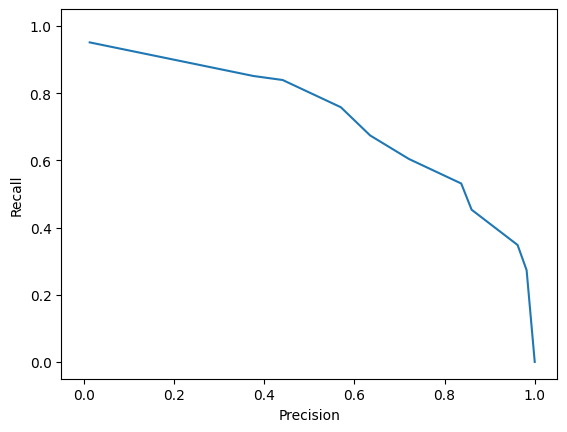

In [7]:
f = open("data_file.csv", "w")
w = csv.writer(f)
_ = w.writerow(["precision", "recall"])
w.writerows([[0.013,0.951],
             [0.376,0.851],
             [0.441,0.839],
             [0.570,0.758],
             [0.635,0.674],
             [0.721,0.604],
             [0.837,0.531],
             [0.860,0.453],
             [0.962,0.348],
             [0.982,0.273],
             [1.0,0.0]])
f.close()
plot_data('data_file.csv')


<h1 id="generator-for-exercise-4">** Generator (for Exercise 4)**</h1>


<font size="4px"><p>Generator class for the GAN</p>
</font>

In [8]:
# You can copy this code to your personal pipeline project or execute it here.
class Generator(nn.Module):
    """
    Generator class for the GAN
    """

    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),
            nn.Tanh(),
        )

    def forward(self, x):
        output = self.model(x)
        output = output.view(x.size(0), 1, 28, 28)
        return output



<h1 id="discriminator-for-exercise-4">** Discriminator (for Exercise 4)**</h1>


<font size="4px"><p>Discriminator class for the GAN</p>
</font>

In [9]:
# You can copy this code to your personal pipeline project or execute it here.
class Discriminator(nn.Module):
    """
    Discriminator class for the GAN
    """
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), 784)
        output = self.model(x)
        return output



<h1 id="exercise-4">** Exercise 4**</h1>


<font size="4px"><p>The method trains a Generative Adversarial Network and is based on: <a href="https://realpython.com/generative-adversarial-networks/">https://realpython.com/generative-adversarial-networks/</a></p>
<p>The Generator network tries to generate convincing images of handwritten digits. The Discriminator needs to detect if the image was created by the Generater or if the image is a real image from a known dataset (MNIST). If both the Generator and the Discriminator are optimized, the Generator is able to create images that are difficult to distinguish from real images. This is goal of a GAN.</p>
<p>This code produces the expected results at first attempt at about 50 epochs.</p>
<dl>
<dt>param batch_size</dt>
<dd><p>The number of images to train in one epoch.</p>
</dd>
<dt>param num_epochs</dt>
<dd><p>The number of epochs to train the gan.</p>
</dd>
<dt>param device</dt>
<dd><p>The computing device to use. If CUDA is installed and working then <span class="title-ref">cuda:0</span> is chosen otherwise 'cpu' is chosen. Note: Training a GAN on the CPU is very slow.</p>
</dd>
</dl>
<p><strong>This method is part of a series of debugging exercises.</strong> <strong>Each Python method of this series contains bug that needs to be found.</strong></p>
<p>It contains at least two bugs: one structural bug and one cosmetic bug. Both bugs are from the original tutorial.</p>
<div class="line-block"><code>1   Changing the batch_size from 32 to 64 triggers the structural bug.</code><br />
<code>2   Can you also spot the cosmetic bug?</code><br />
<code>Note: to fix this bug a thorough understanding of GANs is not necessary.</code></div>
<p>Change the batch size to 64 to trigger the bug with message: ValueError: "Using a target size (torch.Size([128, 1])) that is different to the input size (torch.Size([96, 1])) is deprecated. Please ensure they have the same size."</p>
</font>

In [12]:
# You can copy this code to your personal pipeline project or execute it here.
def train_gan(batch_size: int = 32, num_epochs: int = 100, device: str = 'cuda:0' if torch.cuda.is_available() else 'cpu'):
    """
    Train a simple GAN on the MNIST dataset.

    :param batch_size: Number of images per batch.
    :param num_epochs: Number of training epochs.
    :param device: Target device (e.g., 'cuda:0' or 'cpu').

    This implementation fixes two issues from the original version:

      1. Structural bug: when using a batch size that does not evenly divide the dataset (e.g., 64), the last batch may be smaller than batch_size.  The original code created labels and latent samples with a fixed batch size, causing a mismatch in the loss function. This fix uses the actual batch size of each iteration.

      2. Cosmetic bug: the original code only displayed generated images when the batch index equalled batch_size - 1.  This condition depended on the batch size rather than the number of batches, so the plot would not appear when changing batch_size.  The fix displays generated images at the end of each epoch.
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    try:
        train_set = torchvision.datasets.MNIST(root='.', train=True, download=True, transform=transform)
    except Exception:
        print('Failed to download MNIST, retrying with different URL')
        torchvision.datasets.MNIST.resources = [
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz', 'f68b3c2dcbeaaa9fbdd348bbdeb94873'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz', 'd53e105ee54ea40749a09fcbcd1e9432'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz', '9fb629c4189551a2d022fa330f9573f3'),
            ('https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz', 'ec29112dd5afa0611ce80d1b7f02629c'),
        ]
        train_set = torchvision.datasets.MNIST(root='.', train=True, download=True, transform=transform)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    real_samples, _ = next(iter(train_loader))
    fig = plt.figure()
    for i in range(16):
        sub = fig.add_subplot(4, 4, 1 + i)
        sub.imshow(real_samples[i].reshape(28, 28), cmap='gray_r')
        sub.axis('off')
    fig.tight_layout()
    fig.suptitle('Real images')
    display(fig)
    time.sleep(5)
    discriminator = Discriminator().to(device)
    generator = Generator().to(device)
    lr = 0.0001
    loss_function = nn.BCELoss()
    optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
    optimizer_generator = torch.optim.Adam(generator.parameters(), lr=lr)
    for epoch in range(num_epochs):
        num_batches = len(train_loader)
        for batch_index, (real_samples, _) in enumerate(train_loader):
            current_batch_size = real_samples.size(0)
            real_samples = real_samples.to(device)
            real_labels = torch.ones((current_batch_size, 1), device=device)
            fake_labels = torch.zeros((current_batch_size, 1), device=device)
            optimizer_discriminator.zero_grad()
            output_real = discriminator(real_samples)
            loss_real = loss_function(output_real, real_labels)
            noise = torch.randn((current_batch_size, 100), device=device)
            fake_samples = generator(noise)
            output_fake = discriminator(fake_samples.detach())
            loss_fake = loss_function(output_fake, fake_labels)
            loss_discriminator = loss_real + loss_fake
            loss_discriminator.backward()
            optimizer_discriminator.step()
            optimizer_generator.zero_grad()
            noise = torch.randn((current_batch_size, 100), device=device)
            fake_samples = generator(noise)
            output_fake_for_gen = discriminator(fake_samples)
            loss_generator = loss_function(output_fake_for_gen, real_labels)
            loss_generator.backward()
            optimizer_generator.step()
            if batch_index == num_batches - 1:
                clear_output(wait=True)
                print(f'Epoch [{epoch + 1}/{num_epochs}]')
                print(f'Loss Discriminator: {loss_discriminator:.4f}')
                print(f'Loss Generator:     {loss_generator:.4f}')
                with torch.no_grad():
                    test_noise = torch.randn((16, 100), device=device)
                    test_images = generator(test_noise).cpu()
                grid = torchvision.utils.make_grid(test_images, nrow=4, normalize=True)
                fig = plt.figure(figsize=(6, 6))
                plt.title(f'Generated Images - Epoch {epoch + 1}')
                plt.imshow(grid.permute(1, 2, 0))
                plt.axis('off')
                display(fig)
    print('Training complete!')



Epoch [10/10]
Loss Discriminator: 0.9273
Loss Generator:     1.3273


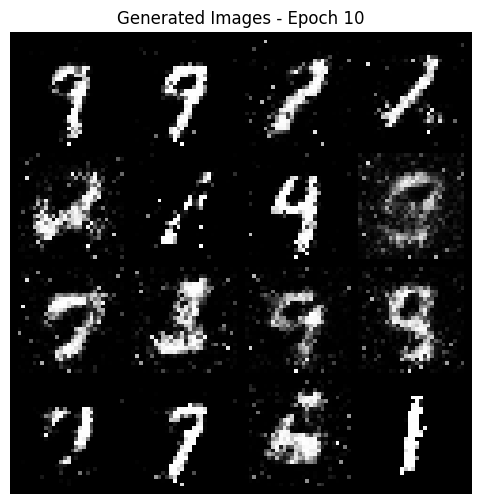

Training complete!


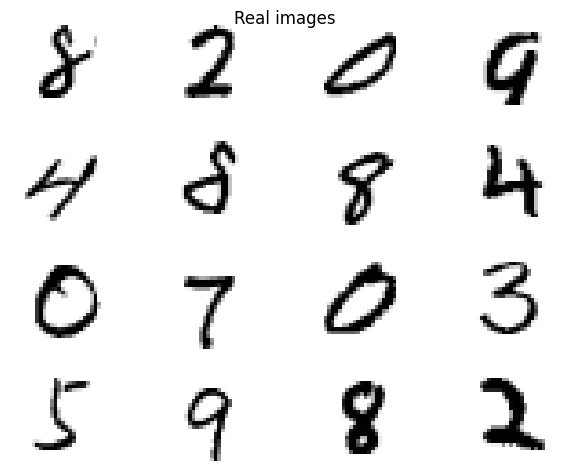

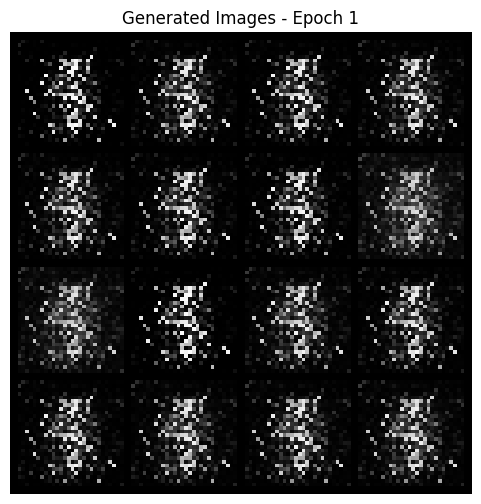

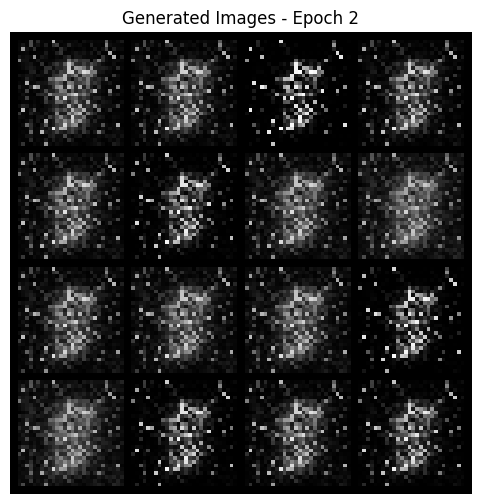

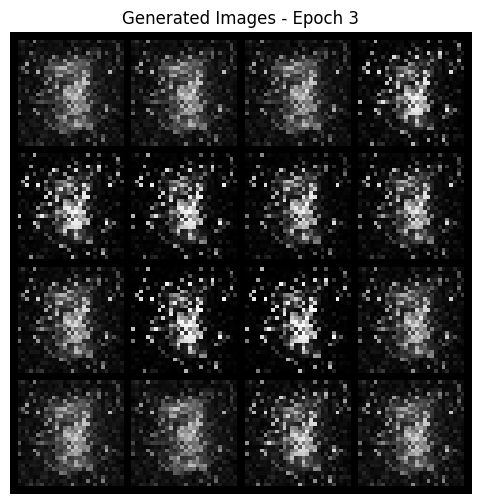

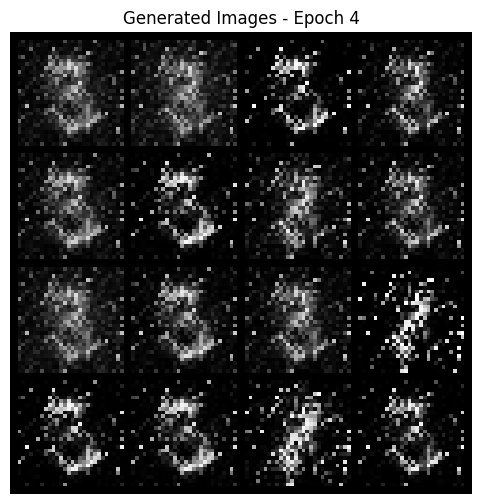

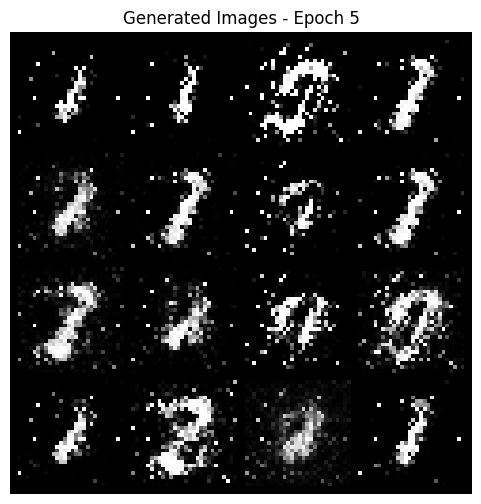

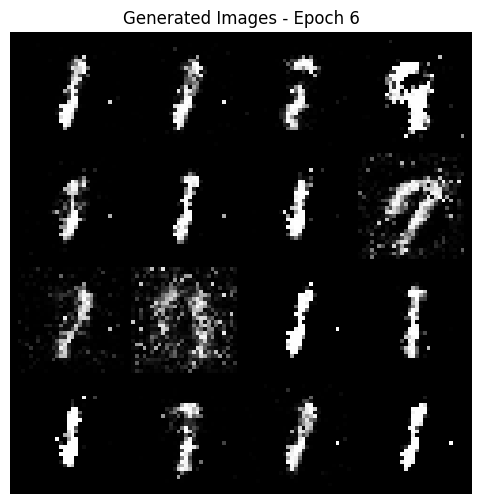

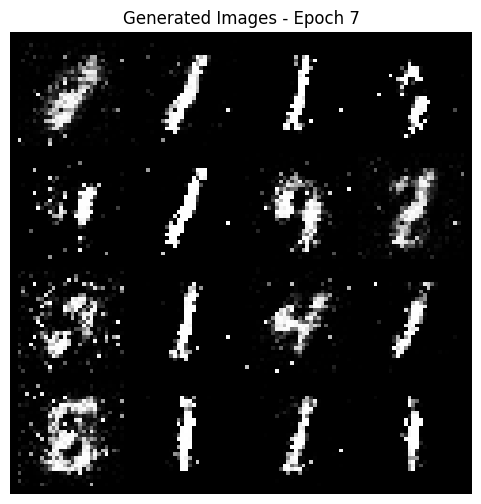

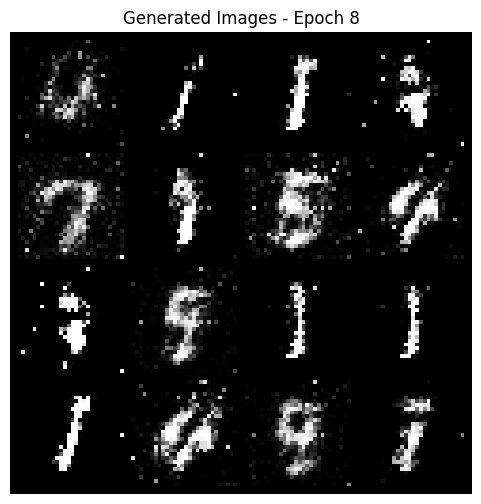

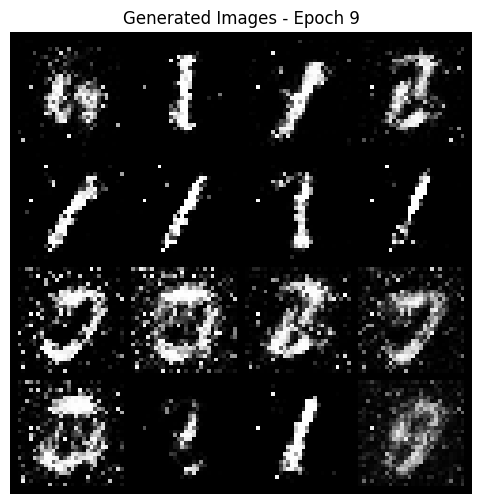

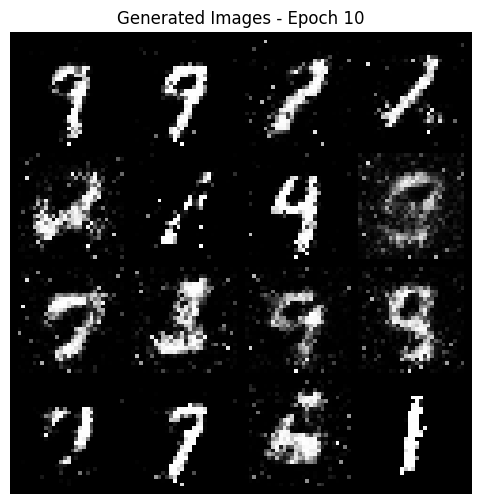

In [14]:
train_gan(batch_size=32, num_epochs=10)
